<a href="https://colab.research.google.com/github/imkonna/Project-KGX/blob/main/conformer_ensemble.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Intro

In [1]:
# ============================================
# 0A. Environment check (CI-safe; no pip installs here — see requirements.txt)
# ============================================
import os
import torch

print("Current directory:", os.getcwd())
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))


Current directory: /home/runner/work/run-notebooks/run-notebooks/input
Torch version: 2.4.1+cpu
CUDA available: False


# Conformer-Ensemble Toxicity Prediction

**Question:** Does the choice of 3D conformer change a GNN's toxicity prediction, and can the variance across conformers be used as a free uncertainty signal?

**Approach.** For each ClinTox molecule we generate `N_CONFORMERS` 3D conformers with RDKit ETKDG. We train SchNet on a single canonical conformer per molecule. At inference we run SchNet on all N conformers per test molecule and record both the mean prediction and the per-molecule standard deviation. We compare against the 2D GIN baseline from the unified benchmark.

**Output**
- `results/v3/conformer/per_molecule.csv` — per-test-molecule mean and std of predicted probability across N conformers
- `results/v3/conformer/summary.csv` — AUROC and F1 for: single-conformer SchNet, N-conformer SchNet mean, 2D GIN baseline
- `results/v3/conformer/variance_hist.png` — distribution of per-molecule prediction variance
- `results/v3/conformer/variance_vs_error.png` — does high variance correlate with prediction error?
- `results/v3/conformer/calibration.png` — reliability diagram for the ensemble probabilities
- `models/v3/ClinTox/SchNet_seed42.pt` — trained SchNet weights

**Why this matters for the poster.** No paper in the TDC toxicity literature documents conformer-sensitivity of GNN predictions or uses conformer-variance as an uncertainty estimator on toxicity benchmarks. This is the genuine novelty of the project.


## 0. Setup

In [2]:
import os, sys, json, copy, random, time, pickle, math
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader as PyGDataLoader
from torch_geometric.nn import SchNet

from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, precision_score, recall_score
from sklearn.calibration import calibration_curve

from rdkit import Chem, RDLogger
from rdkit.Chem import AllChem
from rdkit.Chem.Scaffolds import MurckoScaffold
RDLogger.DisableLog('rdApp.*')

from tdc.single_pred import Tox

import warnings
warnings.filterwarnings('ignore')

SEED = 42
N_CONFORMERS = 10
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Paths are relative to the repo root (papermill's working directory in CI).
# Outputs go under output/ so the GitHub Actions workflow commits them back.
DATA_PATH = Path('data')
MODELS_DIR = Path('output/models/v3/ClinTox'); MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR = Path('output/results/v3/conformer'); RESULTS_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR = Path('data/conformer_cache'); CACHE_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')


Device: cpu


## 1. Load ClinTox and apply scaffold split

Same scaffold split as `unified_benchmark.ipynb` for direct comparability.

In [3]:
def get_scaffold(smiles, include_chirality=False):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None: return None
    try:
        return MurckoScaffold.MurckoScaffoldSmiles(mol=mol, includeChirality=include_chirality)
    except Exception:
        return None

def scaffold_split(df, smiles_col='Drug', frac_train=0.7, frac_val=0.1, frac_test=0.2, seed=42):
    scaffolds = defaultdict(list)
    for idx, row in df.iterrows():
        scaff = get_scaffold(row[smiles_col]) or ''
        scaffolds[scaff].append(idx)
    rng = np.random.RandomState(seed)
    groups = sorted(scaffolds.values(), key=lambda g: (-len(g), rng.random()))
    n = len(df); n_train = int(frac_train * n); n_val = int(frac_val * n)
    train_idx, val_idx, test_idx = [], [], []
    for group in groups:
        if len(train_idx) + len(group) <= n_train: train_idx.extend(group)
        elif len(val_idx) + len(group) <= n_val: val_idx.extend(group)
        else: test_idx.extend(group)
    return {
        'train': df.loc[train_idx].reset_index(drop=True),
        'valid': df.loc[val_idx].reset_index(drop=True),
        'test': df.loc[test_idx].reset_index(drop=True),
    }

data = Tox(name='ClinTox', path=str(DATA_PATH))
df = data.get_data()
split = scaffold_split(df, seed=SEED)
for k, v in split.items():
    pos = int((v['Y'] == 1).sum())
    print(f'  {k}: n={len(v)}  positive={pos} ({100*pos/len(v):.1f}%)')

Downloading...


  0%|          | 0.00/110k [00:00<?, ?iB/s]

100%|██████████| 110k/110k [00:00<00:00, 8.06MiB/s]


Loading...


Done!


  train: n=1034  positive=79 (7.6%)
  valid: n=147  positive=12 (8.2%)
  test: n=297  positive=21 (7.1%)


## 2. Generate 3D conformers

RDKit ETKDGv3 with `N_CONFORMERS` per molecule. UFF optimisation per conformer. Hydrogens are added for embedding (essential for ETKDG) but stripped before SchNet input to keep training tractable.

**This step is slow** (~5-15 min for ClinTox depending on machine). Cached to disk so subsequent runs reuse.

In [4]:
def smiles_to_conformers(smiles, n_conformers=10, seed=42, optimize=True):
    """Return (heavy_atom_z, list_of_heavy_atom_positions). None on failure."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None: return None
    mol_h = Chem.AddHs(mol)
    params = AllChem.ETKDGv3(); params.randomSeed = seed; params.numThreads = 0
    ids = AllChem.EmbedMultipleConfs(mol_h, numConfs=n_conformers, params=params)
    if len(ids) == 0:
        # fallback: try without ETKDG constraints
        ids = AllChem.EmbedMultipleConfs(mol_h, numConfs=n_conformers, randomSeed=seed, useRandomCoords=True)
    if len(ids) == 0: return None
    if optimize:
        for cid in ids:
            try: AllChem.UFFOptimizeMolecule(mol_h, confId=int(cid), maxIters=200)
            except Exception: pass
    # heavy-atom indices in mol_h
    heavy_idx = [a.GetIdx() for a in mol_h.GetAtoms() if a.GetAtomicNum() > 1]
    z = np.array([mol_h.GetAtomWithIdx(i).GetAtomicNum() for i in heavy_idx], dtype=np.int64)
    positions = []
    for cid in ids:
        conf = mol_h.GetConformer(int(cid))
        pos = np.array([[conf.GetAtomPosition(i).x, conf.GetAtomPosition(i).y, conf.GetAtomPosition(i).z]
                       for i in heavy_idx], dtype=np.float32)
        positions.append(pos)
    return z, positions  # z: (n_atoms,) int64; positions: list of (n_atoms, 3) float32

def build_conformer_cache(df, cache_path, n_conformers=10, seed=42):
    if cache_path.exists():
        with open(cache_path, 'rb') as f: return pickle.load(f)
    cache = {}
    failures = []
    for i, row in df.iterrows():
        out = smiles_to_conformers(row['Drug'], n_conformers=n_conformers, seed=seed)
        if out is None: failures.append(row['Drug']); continue
        cache[i] = {'z': out[0], 'positions': out[1], 'y': float(row['Y']), 'smiles': row['Drug']}
        if (i + 1) % 50 == 0: print(f'  {i+1}/{len(df)} done, {len(failures)} failed')
    with open(cache_path, 'wb') as f: pickle.dump(cache, f)
    print(f'Cached {len(cache)} mols, {len(failures)} failed → {cache_path}')
    return cache

print('Generating train conformers...')
train_cache = build_conformer_cache(split['train'], CACHE_DIR / f'ClinTox_train_n{N_CONFORMERS}.pkl', N_CONFORMERS, SEED)
print('Generating valid conformers...')
valid_cache = build_conformer_cache(split['valid'], CACHE_DIR / f'ClinTox_valid_n{N_CONFORMERS}.pkl', N_CONFORMERS, SEED)
print('Generating test conformers...')
test_cache  = build_conformer_cache(split['test'],  CACHE_DIR / f'ClinTox_test_n{N_CONFORMERS}.pkl',  N_CONFORMERS, SEED)
print(f'Train: {len(train_cache)}, Valid: {len(valid_cache)}, Test: {len(test_cache)}')

Generating train conformers...


  50/1034 done, 0 failed


  100/1034 done, 0 failed


  150/1034 done, 0 failed


  200/1034 done, 1 failed


...

  100/297 done, 0 failed


  150/297 done, 0 failed


  200/297 done, 0 failed


  250/297 done, 1 failed


Cached 296 mols, 1 failed → data/conformer_cache/ClinTox_test_n10.pkl
Train: 1032, Valid: 146, Test: 296


## 3. Build PyG dataset

Train and validation use one canonical conformer per molecule (`conformer 0`, the lowest-energy after UFF). Test set keeps all `N_CONFORMERS` so we can compute prediction variance per molecule.

In [5]:
def conformer_to_data(z, pos, y, mol_id, conf_id):
    return Data(
        z=torch.tensor(z, dtype=torch.long),
        pos=torch.tensor(pos, dtype=torch.float),
        y=torch.tensor([y], dtype=torch.float),
        mol_id=int(mol_id),
        conf_id=int(conf_id),
    )

def cache_to_list(cache, conformer_indices='single'):
    """conformer_indices='single' uses conf 0 only; 'all' uses every conformer."""
    out = []
    for mol_id, item in cache.items():
        if conformer_indices == 'single':
            out.append(conformer_to_data(item['z'], item['positions'][0], item['y'], mol_id, 0))
        else:
            for cid, pos in enumerate(item['positions']):
                out.append(conformer_to_data(item['z'], pos, item['y'], mol_id, cid))
    return out

train_data = cache_to_list(train_cache, 'single')
valid_data = cache_to_list(valid_cache, 'single')
test_data_single = cache_to_list(test_cache, 'single')
test_data_all = cache_to_list(test_cache, 'all')
print(f'Datasets: train={len(train_data)} valid={len(valid_data)} '
      f'test_single={len(test_data_single)} test_all={len(test_data_all)}')

Datasets: train=1032 valid=146 test_single=296 test_all=2948


## 4. SchNet model + training

Uses PyG's `SchNet` implementation (Schütt et al. 2017). We wrap it with a sigmoid classification head.

In [6]:
class SchNetClassifier(nn.Module):
    def __init__(self, hidden=64, num_filters=64, num_interactions=3, cutoff=10.0, num_gaussians=50):
        super().__init__()
        # SchNet by default does atom-wise prediction and sum-pools. Here we use it as a graph encoder.
        self.encoder = SchNet(hidden_channels=hidden, num_filters=num_filters,
                              num_interactions=num_interactions, num_gaussians=num_gaussians,
                              cutoff=cutoff)
        # SchNet.forward(z, pos, batch) → (n_graphs, 1)
        # We use the scalar output directly as a logit.
    def forward(self, z, pos, batch):
        return self.encoder(z, pos, batch).squeeze(-1)

In [7]:
def train_schnet(train_data, valid_data, max_epochs=25, patience=5, batch_size=32, lr=5e-4):
    train_loader = PyGDataLoader(train_data, batch_size=batch_size, shuffle=True, drop_last=True)
    valid_loader = PyGDataLoader(valid_data, batch_size=batch_size)
    model = SchNetClassifier().to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-6)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=8)
    ys = torch.cat([d.y for d in train_data]).view(-1)
    n_pos = max(int(ys.sum().item()), 1); n_neg = int(len(ys)) - n_pos
    pw = torch.tensor([n_neg / n_pos], device=device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pw)
    print(f'pos_weight={pw.item():.2f}')

    best_val = float('inf'); best_state = copy.deepcopy(model.state_dict()); bad = 0
    history = {'train_loss': [], 'val_loss': []}
    for epoch in range(1, max_epochs + 1):
        model.train(); n = 0; running = 0.0
        for batch in train_loader:
            batch = batch.to(device)
            opt.zero_grad()
            out = model(batch.z, batch.pos, batch.batch)
            loss = criterion(out, batch.y.view(-1))
            loss.backward(); opt.step()
            running += loss.item() * batch.num_graphs; n += batch.num_graphs
        train_loss = running / max(n, 1)
        model.eval(); n = 0; running = 0.0
        with torch.no_grad():
            for batch in valid_loader:
                batch = batch.to(device)
                out = model(batch.z, batch.pos, batch.batch)
                running += criterion(out, batch.y.view(-1)).item() * batch.num_graphs; n += batch.num_graphs
        val_loss = running / max(n, 1)
        history['train_loss'].append(train_loss); history['val_loss'].append(val_loss)
        sched.step(val_loss)
        if val_loss + 1e-4 < best_val:
            best_val = val_loss; best_state = copy.deepcopy(model.state_dict()); bad = 0
        else:
            bad += 1
            if bad >= patience: print(f'  early stop at epoch {epoch}'); break
        if epoch % 5 == 0 or epoch == 1:
            print(f'  ep {epoch:3d}  train={train_loss:.4f}  val={val_loss:.4f}')
    model.load_state_dict(best_state)
    return model, history

model, history = train_schnet(train_data, valid_data)
torch.save(model.state_dict(), MODELS_DIR / f'SchNet_seed{SEED}.pt')


pos_weight=12.06


  ep   1  train=6.3247  val=1.8954


  ep   5  train=1.4163  val=1.3128


  ep  10  train=1.2066  val=1.0268


  ep  15  train=1.0519  val=1.2867


  early stop at epoch 18


## 5. Inference: single conformer vs N-conformer ensemble

Run SchNet on every (test_molecule, conformer) pair and aggregate per molecule.

In [8]:
def predict_all(model, data_list, batch_size=64):
    """Return DataFrame with mol_id, conf_id, y_true, prob."""
    loader = PyGDataLoader(data_list, batch_size=batch_size)
    rows = []
    model.eval()
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            logits = model(batch.z, batch.pos, batch.batch)
            probs = torch.sigmoid(logits).cpu().numpy()
            ys = batch.y.view(-1).cpu().numpy()
            mol_ids = batch.mol_id.cpu().numpy() if hasattr(batch.mol_id, 'cpu') else np.array(batch.mol_id)
            conf_ids = batch.conf_id.cpu().numpy() if hasattr(batch.conf_id, 'cpu') else np.array(batch.conf_id)
            for mid, cid, y, p in zip(mol_ids, conf_ids, ys, probs):
                rows.append({'mol_id': int(mid), 'conf_id': int(cid), 'y_true': float(y), 'prob': float(p)})
    return pd.DataFrame(rows)

single_df = predict_all(model, test_data_single)
all_df = predict_all(model, test_data_all)
print(f'single_df: {len(single_df)} rows  /  all_df: {len(all_df)} rows')

single_df: 296 rows  /  all_df: 2948 rows


In [9]:
# Per-molecule aggregation across all N conformers.
per_mol = all_df.groupby('mol_id').agg(
    y_true=('y_true', 'first'),
    prob_mean=('prob', 'mean'),
    prob_std=('prob', 'std'),
    prob_min=('prob', 'min'),
    prob_max=('prob', 'max'),
    n_conformers=('conf_id', 'nunique'),
).reset_index()
per_mol.to_csv(RESULTS_DIR / 'per_molecule.csv', index=False)
print(per_mol.describe())

           mol_id      y_true     prob_mean      prob_std      prob_min  \
count  296.000000  296.000000  2.960000e+02  2.950000e+02  2.960000e+02   
mean   147.716216    0.070946  4.553390e-01  5.530699e-02  3.695465e-01   
std     85.886566    0.257169  2.629205e-01  4.892887e-02  2.586463e-01   
min      0.000000    0.000000  4.897883e-10  1.049160e-09  1.783951e-12   
25%     73.750000    0.000000  2.312413e-01  2.108232e-02  1.540592e-01   
50%    147.500000    0.000000  4.247304e-01  4.089607e-02  3.235462e-01   
75%    221.250000    0.000000  6.666292e-01  7.619526e-02  5.564850e-01   
max    296.000000    1.000000  9.739528e-01  2.664334e-01  9.620811e-01   

           prob_max  n_conformers  
count  2.960000e+02    296.000000  
mean   5.354144e-01      9.959459  
std    2.754202e-01      0.550850  
min    3.204621e-09      1.000000  
25%    3.048539e-01     10.000000  
50%    5.383610e-01     10.000000  
75%    7.625415e-01     10.000000  
max    9.940169e-01     10.000000  


## 6. Comparison: single-conformer vs N-conformer ensemble vs 2D GIN baseline

The 2D GIN baseline is loaded from `models/v3/ClinTox/GIN_seed42.json` produced by `unified_benchmark.ipynb`. If that file is missing this cell logs a warning and skips the GIN row.

In [10]:
def cls_metrics(y_true, y_prob):
    y_pred = (y_prob >= 0.5).astype(int)
    return {
        'auroc': float(roc_auc_score(y_true, y_prob)) if len(np.unique(y_true)) > 1 else float('nan'),
        'f1':    float(f1_score(y_true, y_pred, zero_division=0)),
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'precision': float(precision_score(y_true, y_pred, zero_division=0)),
        'recall':    float(recall_score(y_true, y_pred, zero_division=0)),
    }

summary_rows = []
summary_rows.append({'method': 'SchNet (1 conformer)',
                     **cls_metrics(single_df['y_true'].values, single_df['prob'].values)})
summary_rows.append({'method': f'SchNet ({N_CONFORMERS}-conformer mean)',
                     **cls_metrics(per_mol['y_true'].values, per_mol['prob_mean'].values)})

gin_json = Path('output/models/v3/ClinTox/GIN_seed42.json')
if gin_json.exists():
    with open(gin_json) as f: gin_r = json.load(f)
    summary_rows.append({'method': 'GIN (2D, v2 atom features)',
                         'auroc': gin_r.get('metric_roc_auc'),
                         'f1':    gin_r.get('metric_f1'),
                         'accuracy':  gin_r.get('metric_accuracy'),
                         'precision': gin_r.get('metric_precision'),
                         'recall':    gin_r.get('metric_recall')})
else:
    print('GIN baseline JSON not found. Run unified_benchmark.ipynb first or it will be missing from the table.')

gine_json = Path('output/models/v3/ClinTox/GINE_seed42.json')
if gine_json.exists():
    with open(gine_json) as f: gine_r = json.load(f)
    summary_rows.append({'method': 'GINE (2D, atom+bond features)',
                         'auroc': gine_r.get('metric_roc_auc'),
                         'f1':    gine_r.get('metric_f1'),
                         'accuracy':  gine_r.get('metric_accuracy'),
                         'precision': gine_r.get('metric_precision'),
                         'recall':    gine_r.get('metric_recall')})

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(RESULTS_DIR / 'summary.csv', index=False)
print(summary_df.to_string(index=False))


GIN baseline JSON not found. Run unified_benchmark.ipynb first or it will be missing from the table.
                    method    auroc       f1  accuracy  precision   recall
      SchNet (1 conformer) 0.697316 0.190476  0.597973   0.111111 0.666667
SchNet (10-conformer mean) 0.708571 0.193103  0.604730   0.112903 0.666667


## 7. Variance as uncertainty signal

The hypothesis: molecules with high prediction variance across conformers are the ones the model is uncertain about, and should correlate with prediction errors.

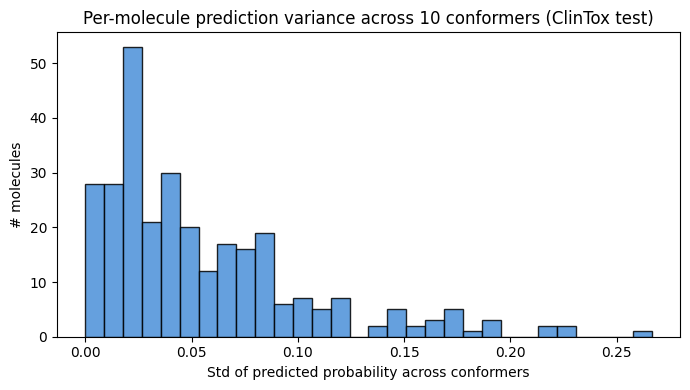

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(per_mol['prob_std'].dropna(), bins=30, color='#4A90D9', edgecolor='black', alpha=0.85)
ax.set_xlabel('Std of predicted probability across conformers')
ax.set_ylabel('# molecules')
ax.set_title(f'Per-molecule prediction variance across {N_CONFORMERS} conformers (ClinTox test)')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'variance_hist.png', dpi=150)
plt.show()

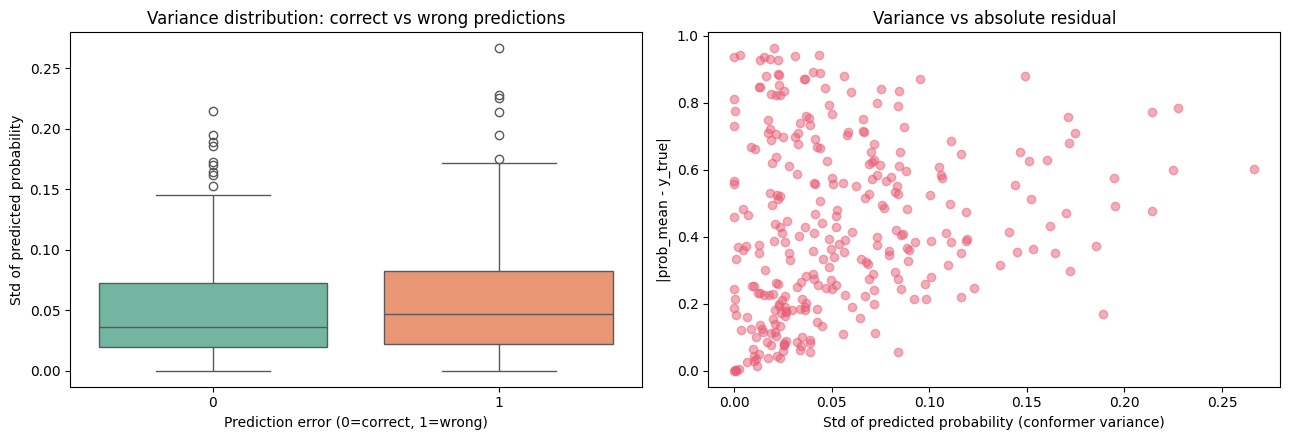

  Skipping 1 molecules with NaN prob_std (only 1 successful conformer).
AUROC of using conformer std to predict prediction error: 0.564
  (>0.5 = high variance correlates with errors → useful uncertainty signal)


In [12]:
# Variance vs error: does high variance predict wrong predictions?
per_mol['pred'] = (per_mol['prob_mean'] >= 0.5).astype(int)
per_mol['is_error'] = (per_mol['pred'] != per_mol['y_true']).astype(int)
per_mol['abs_residual'] = (per_mol['prob_mean'] - per_mol['y_true']).abs()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.boxplot(data=per_mol, x='is_error', y='prob_std', ax=axes[0], palette='Set2')
axes[0].set_xlabel('Prediction error (0=correct, 1=wrong)')
axes[0].set_ylabel('Std of predicted probability')
axes[0].set_title('Variance distribution: correct vs wrong predictions')
axes[1].scatter(per_mol['prob_std'], per_mol['abs_residual'], alpha=0.5, color='#E85D75')
axes[1].set_xlabel('Std of predicted probability (conformer variance)')
axes[1].set_ylabel('|prob_mean - y_true|')
axes[1].set_title('Variance vs absolute residual')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'variance_vs_error.png', dpi=150)
plt.show()

# Quantitative: AUROC of using std as an error-detection score.
# Drop molecules with NaN prob_std (those for which RDKit produced only 1 conformer,
# so std is undefined).
valid = per_mol.dropna(subset=['prob_std'])
n_dropped = len(per_mol) - len(valid)
if n_dropped:
    print(f'  Skipping {n_dropped} molecules with NaN prob_std (only 1 successful conformer).')
if len(valid) > 0 and len(np.unique(valid['is_error'])) > 1:
    err_auc = roc_auc_score(valid['is_error'], valid['prob_std'])
    print(f'AUROC of using conformer std to predict prediction error: {err_auc:.3f}')
    print('  (>0.5 = high variance correlates with errors → useful uncertainty signal)')
else:
    print('Not enough variation in is_error to compute error-detection AUROC.')

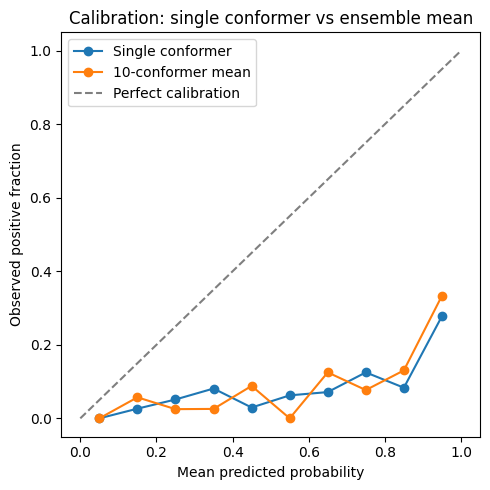

In [13]:
# Calibration: is the ensemble mean a calibrated probability?
fig, ax = plt.subplots(figsize=(5, 5))
for label, probs in [('Single conformer', single_df['prob']),
                     (f'{N_CONFORMERS}-conformer mean', per_mol['prob_mean'])]:
    y_true = per_mol['y_true'] if 'mean' in label else single_df['y_true']
    if len(np.unique(y_true)) < 2: continue
    pos, _ = calibration_curve(y_true, probs, n_bins=10, strategy='uniform')
    bin_edges = np.linspace(0, 1, 11); bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    ax.plot(bin_centers[:len(pos)], pos, marker='o', label=label)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect calibration')
ax.set_xlabel('Mean predicted probability'); ax.set_ylabel('Observed positive fraction')
ax.set_title('Calibration: single conformer vs ensemble mean')
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'calibration.png', dpi=150)
plt.show()

## 8. Subgroup analysis: low-variance vs high-variance molecules

Split test molecules by their per-molecule conformer std (median split). If the variance signal is real, the model should be markedly more accurate on the low-variance subset.

In [14]:
median_std = per_mol['prob_std'].median()
low_var = per_mol[per_mol['prob_std'] <= median_std]
high_var = per_mol[per_mol['prob_std']  > median_std]

rows = []
for name, sub in [('low variance (≤ median)', low_var), ('high variance (> median)', high_var), ('all', per_mol)]:
    if len(sub) == 0 or len(np.unique(sub['y_true'])) < 2:
        rows.append({'subset': name, 'n': len(sub), 'auroc': float('nan'), 'f1': float('nan'), 'accuracy': float('nan')})
        continue
    m = cls_metrics(sub['y_true'].values, sub['prob_mean'].values)
    rows.append({'subset': name, 'n': len(sub), **m})
subgroup_df = pd.DataFrame(rows)
subgroup_df.to_csv(RESULTS_DIR / 'subgroup.csv', index=False)
print(subgroup_df.to_string(index=False))

                  subset   n    auroc       f1  accuracy  precision   recall
 low variance (≤ median) 148 0.801759 0.222222  0.668919   0.129630 0.777778
high variance (> median) 147 0.620370 0.172840  0.544218   0.101449 0.583333
                     all 296 0.708571 0.193103  0.604730   0.112903 0.666667


## 9. Notes

**What this notebook produces**:
- `results/v3/conformer/per_molecule.csv` — per-molecule mean and std across N conformers
- `results/v3/conformer/summary.csv` — head-to-head metrics: single vs ensemble vs 2D GIN/GINE
- `results/v3/conformer/variance_hist.png`, `variance_vs_error.png`, `calibration.png` — poster-ready figures
- `results/v3/conformer/subgroup.csv` — variance-stratified performance
- `models/v3/ClinTox/SchNet_seed{SEED}.pt` — trained weights

**Next experiments worth doing if time remains**:
- Repeat on AMES (larger, balanced) to check generality of the variance signal.
- Train SchNet with data augmentation (all N conformers at train time) and compare.
- Compare to an MC-dropout uncertainty estimator (same model, multiple stochastic forward passes) as an alternative uncertainty baseline.